# Profiling plots

## Load the data

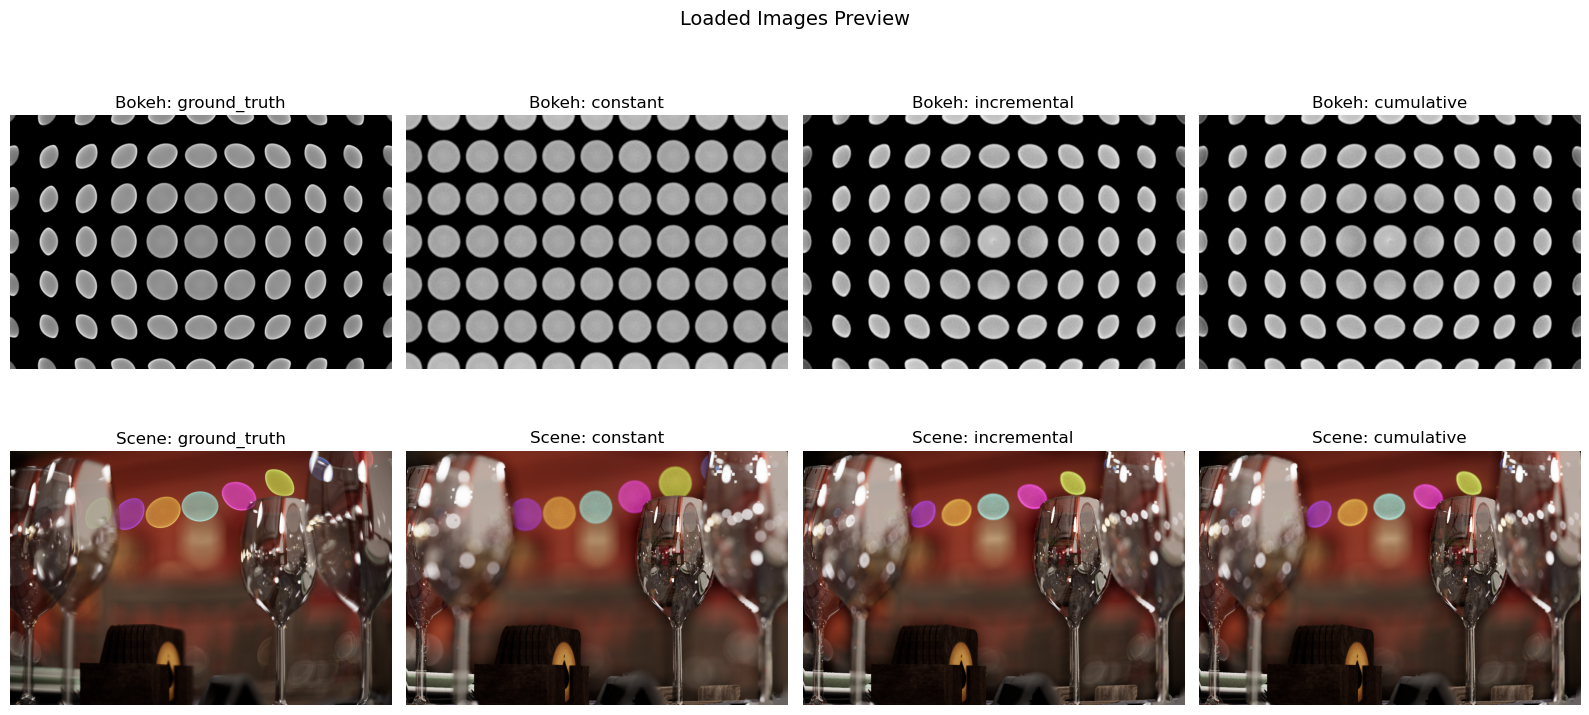


Data loaded from: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260317_153129
Output will be saved to: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260317_153129\analysis_output

Bokeh Config images shape: (800, 1200, 3)
Bokeh Config images dtype: float32
Bokeh Config images range: [0.000, 0.910]
Scene images shape: (800, 1200, 3)
Loaded 7 tap count variations for constant, incremental and cumulative modes
Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260317_153129\analysis_output\loaded_images_preview.svg


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import json
from skimage.metrics import structural_similarity as ssim

# Configuration
DATA_ROOT = Path(r"C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260318_113144")
OUTPUT_DIR = DATA_ROOT / "analysis_output"
OUTPUT_DIR.mkdir(exist_ok=True)

BOKEH_CONFIG_DIR = DATA_ROOT / "bokeh_config"
SCENE_DIR = DATA_ROOT / "scene"

# Helper functions
def load_image(path):
    """Load image as numpy array normalized to [0, 1] range (RGB only)."""
    img = Image.open(path)
    # Convert to RGB if RGBA (remove alpha channel)
    if img.mode == 'RGBA':
        img = img.convert('RGB')
    elif img.mode != 'RGB':
        img = img.convert('RGB')
    
    img_arr = np.array(img)
    # Normalize to [0, 1] range
    if img_arr.dtype == np.uint8:
        return img_arr.astype(np.float32) / 255.0
    elif img_arr.dtype == np.uint16:
        return img_arr.astype(np.float32) / 65535.0
    else:
        return img_arr.astype(np.float32)

def load_json(path):
    """Load JSON file."""
    with open(path, 'r') as f:
        return json.load(f)

# Load bokeh_config images
bokeh_images = {
    'ground_truth': load_image(BOKEH_CONFIG_DIR / "ground_truth" / "realistic_lens_ground_truth.png"),
    'constant': load_image(BOKEH_CONFIG_DIR / "images" / "gather_dof_spatially_constant.png"),
    'incremental': load_image(BOKEH_CONFIG_DIR / "images" / "gather_dof_spatially_varying_incremental.png"),
    'cumulative': load_image(BOKEH_CONFIG_DIR / "images" / "gather_dof_spatially_varying_cumulative.png"),
}

# Load scene images
scene_images = {
    'ground_truth': load_image(SCENE_DIR / "ground_truth" / "lens_simulation_ground_truth.png"),
    'constant': load_image(SCENE_DIR / "images" / "gather_dof_spatially_constant.png"),
    'incremental': load_image(SCENE_DIR / "images" / "gather_dof_spatially_varying_incremental.png"),
    'cumulative': load_image(SCENE_DIR / "images" / "gather_dof_spatially_varying_cumulative.png"),
}

# Load profiling JSON data for bokeh_config
bokeh_profiling = {
    'constant': load_json(BOKEH_CONFIG_DIR / "profiling" / "gather_dof_spatially_constant_detail.json"),
    'incremental': load_json(BOKEH_CONFIG_DIR / "profiling" / "gather_dof_spatially_varying_incremental_detail.json"),
    'cumulative': load_json(BOKEH_CONFIG_DIR / "profiling" / "gather_dof_spatially_varying_cumulative_detail.json"),
}

# Load profiling JSON data for scene
scene_profiling = {
    'constant': load_json(SCENE_DIR / "profiling" / "gather_dof_spatially_constant_detail.json"),
    'incremental': load_json(SCENE_DIR / "profiling" / "gather_dof_spatially_varying_incremental_detail.json"),
    'cumulative': load_json(SCENE_DIR / "profiling" / "gather_dof_spatially_varying_cumulative_detail.json"),
}

# Load tap count comparison data for bokeh_config
tap_counts = [1, 5, 10, 20, 40, 60, 80]
tap_count_data = {'constant': {}, 'incremental': {}, 'cumulative': {}}

for mode in ['constant', 'incremental', 'cumulative']:
    for tc in tap_counts:
        tap_dir = BOKEH_CONFIG_DIR / "tap_count_comparison" / mode
        tap_count_data[mode][tc] = {
            'image': load_image(tap_dir / f"gather_dof_tap_count_{tc:02d}.png"),
            'profiling': load_json(tap_dir / f"tap_count_{tc:02d}_detail.json"),
        }

# Display sample images to verify loading
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Loaded Images Preview", fontsize=14)

for idx, (name, img) in enumerate(bokeh_images.items()):
    axes[0, idx].imshow(img)
    axes[0, idx].set_title(f"Bokeh: {name}")
    axes[0, idx].axis('off')

for idx, (name, img) in enumerate(scene_images.items()):
    axes[1, idx].imshow(img)
    axes[1, idx].set_title(f"Scene: {name}")
    axes[1, idx].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loaded_images_preview.svg", format='svg', bbox_inches='tight')
plt.show()

print(f"\nData loaded from: {DATA_ROOT}")
print(f"Output will be saved to: {OUTPUT_DIR}")
print(f"\nBokeh Config images shape: {bokeh_images['ground_truth'].shape}")
print(f"Bokeh Config images dtype: {bokeh_images['ground_truth'].dtype}")
print(f"Bokeh Config images range: [{bokeh_images['ground_truth'].min():.3f}, {bokeh_images['ground_truth'].max():.3f}]")
print(f"Scene images shape: {scene_images['ground_truth'].shape}")
print(f"Loaded {len(tap_counts)} tap count variations for constant, incremental and cumulative modes")
print(f"Saved: {OUTPUT_DIR / 'loaded_images_preview.svg'}")


## Quality

BOKEH CONFIG - Quality Metrics
Constant        - L1: 0.168964, PSNR: 10.35 dB, SSIM: 0.5569
Incremental     - L1: 0.045352, PSNR: 20.52 dB, SSIM: 0.8792
Cumulative      - L1: 0.045390, PSNR: 20.52 dB, SSIM: 0.8788

SCENE - Quality Metrics
Constant        - L1: 0.078909, PSNR: 17.21 dB, SSIM: 0.6819
Incremental     - L1: 0.075108, PSNR: 17.31 dB, SSIM: 0.6668
Cumulative      - L1: 0.075108, PSNR: 17.31 dB, SSIM: 0.6668


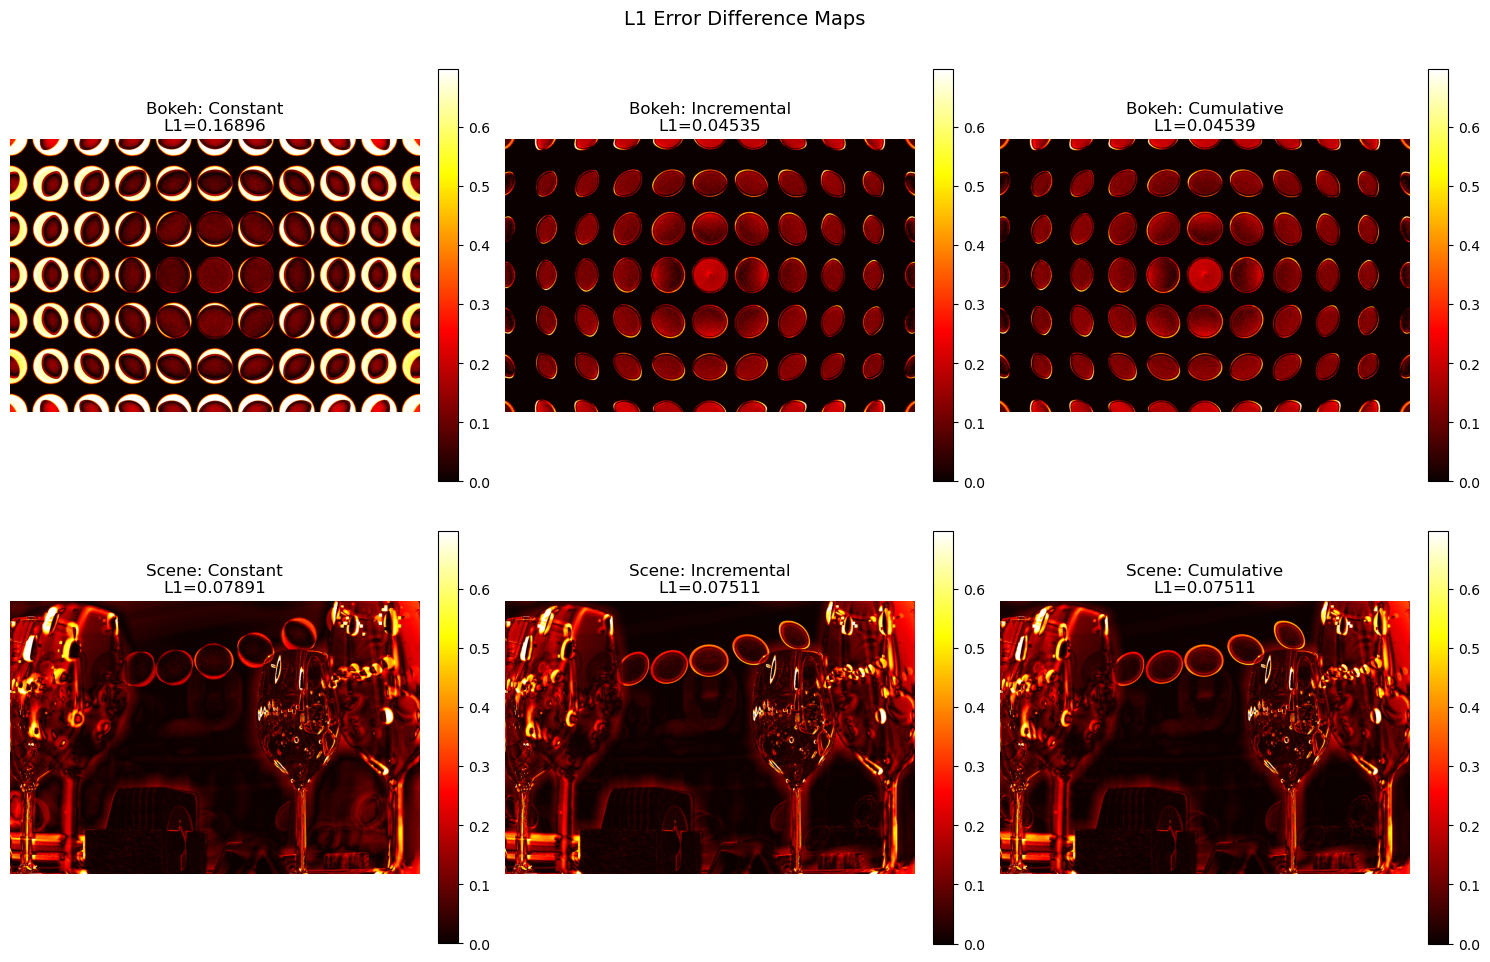


Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260317_153129\analysis_output\quality_l1_difference_maps.svg
Color scale vmax: 0.6980 (99th percentile)


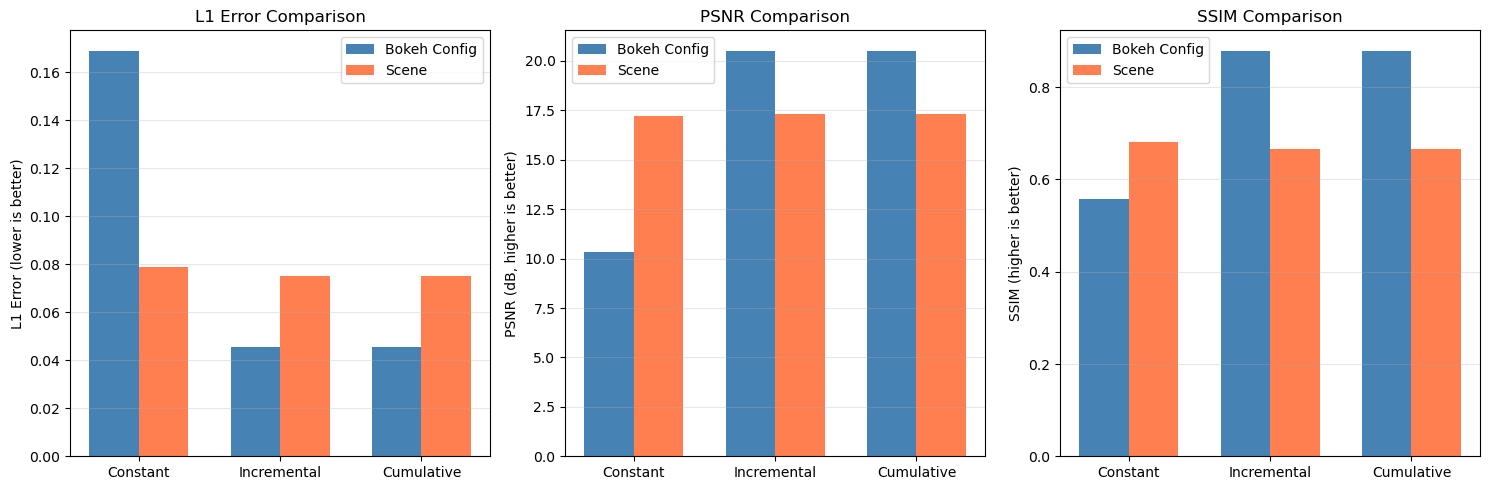

Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260317_153129\analysis_output\quality_metrics_comparison.svg


In [6]:
# Quality Metrics Functions
def compute_l1_error(img1, img2):
    """Compute Mean Absolute Error (L1) between two images."""
    return np.mean(np.abs(img1.astype(np.float32) - img2.astype(np.float32)))

def compute_psnr(img1, img2, max_val=1.0):
    """Compute Peak Signal-to-Noise Ratio."""
    img1_f = img1.astype(np.float32)
    img2_f = img2.astype(np.float32)
    mse = np.mean((img1_f - img2_f) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10((max_val ** 2) / mse)

def compute_ssim(img1, img2):
    """Compute Structural Similarity Index."""
    # For multichannel (RGB) images, data_range=1.0 since images are normalized
    return ssim(img1.astype(np.float32), img2.astype(np.float32), 
                data_range=1.0, channel_axis=2)

def compute_l1_difference_map(img1, img2):
    """Compute L1 difference map for visualization (no fixed scaling)."""
    diff = np.abs(img1.astype(np.float32) - img2.astype(np.float32))
    diff_gray = np.mean(diff, axis=2)  # Average across channels
    return diff_gray  # Return raw values, let colorbar show actual scale

# Compute metrics for bokeh_config
print("=" * 60)
print("BOKEH CONFIG - Quality Metrics")
print("=" * 60)

bokeh_metrics = {}
gt_bokeh = bokeh_images['ground_truth']

for method in ['constant', 'incremental', 'cumulative']:
    l1 = compute_l1_error(gt_bokeh, bokeh_images[method])
    psnr = compute_psnr(gt_bokeh, bokeh_images[method])
    ssim_val = compute_ssim(gt_bokeh, bokeh_images[method])
    bokeh_metrics[method] = {'L1': l1, 'PSNR': psnr, 'SSIM': ssim_val}
    print(f"{method.capitalize():15} - L1: {l1:.6f}, PSNR: {psnr:.2f} dB, SSIM: {ssim_val:.4f}")

# Compute metrics for scene
print("\n" + "=" * 60)
print("SCENE - Quality Metrics")
print("=" * 60)

scene_metrics = {}
gt_scene = scene_images['ground_truth']

for method in ['constant', 'incremental', 'cumulative']:
    l1 = compute_l1_error(gt_scene, scene_images[method])
    psnr = compute_psnr(gt_scene, scene_images[method])
    ssim_val = compute_ssim(gt_scene, scene_images[method])
    scene_metrics[method] = {'L1': l1, 'PSNR': psnr, 'SSIM': ssim_val}
    print(f"{method.capitalize():15} - L1: {l1:.6f}, PSNR: {psnr:.2f} dB, SSIM: {ssim_val:.4f}")

# Compute all difference maps first to determine shared color scale
all_diff_maps = {}
methods = ['constant', 'incremental', 'cumulative']
for method in methods:
    all_diff_maps[('bokeh', method)] = compute_l1_difference_map(gt_bokeh, bokeh_images[method])
    all_diff_maps[('scene', method)] = compute_l1_difference_map(gt_scene, scene_images[method])

# Find global max for consistent color scale
global_max = max(dm.max() for dm in all_diff_maps.values())
# Use a sensible percentile to avoid outliers dominating the scale
global_vmax = np.percentile(np.concatenate([dm.flatten() for dm in all_diff_maps.values()]), 99)

# Visualize L1 difference maps
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("L1 Error Difference Maps", fontsize=14)

for idx, method in enumerate(methods):
    # Bokeh config
    diff_map = all_diff_maps[('bokeh', method)]
    im = axes[0, idx].imshow(diff_map, cmap='hot', vmin=0, vmax=global_vmax)
    axes[0, idx].set_title(f"Bokeh: {method.capitalize()}\nL1={bokeh_metrics[method]['L1']:.5f}")
    axes[0, idx].axis('off')
    plt.colorbar(im, ax=axes[0, idx], fraction=0.046, pad=0.04)
    
    # Scene
    diff_map = all_diff_maps[('scene', method)]
    im = axes[1, idx].imshow(diff_map, cmap='hot', vmin=0, vmax=global_vmax)
    axes[1, idx].set_title(f"Scene: {method.capitalize()}\nL1={scene_metrics[method]['L1']:.5f}")
    axes[1, idx].axis('off')
    plt.colorbar(im, ax=axes[1, idx], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "quality_l1_difference_maps.svg", format='svg', bbox_inches='tight')
plt.show()
print(f"\nSaved: {OUTPUT_DIR / 'quality_l1_difference_maps.svg'}")
print(f"Color scale vmax: {global_vmax:.4f} (99th percentile)")

# Create summary bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

methods_labels = ['Constant', 'Incremental', 'Cumulative']
x = np.arange(len(methods_labels))
width = 0.35

# L1 Error
bokeh_l1 = [bokeh_metrics[m]['L1'] for m in methods]
scene_l1 = [scene_metrics[m]['L1'] for m in methods]
axes[0].bar(x - width/2, bokeh_l1, width, label='Bokeh Config', color='steelblue')
axes[0].bar(x + width/2, scene_l1, width, label='Scene', color='coral')
axes[0].set_ylabel('L1 Error (lower is better)')
axes[0].set_title('L1 Error Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods_labels)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# PSNR
bokeh_psnr = [bokeh_metrics[m]['PSNR'] for m in methods]
scene_psnr = [scene_metrics[m]['PSNR'] for m in methods]
axes[1].bar(x - width/2, bokeh_psnr, width, label='Bokeh Config', color='steelblue')
axes[1].bar(x + width/2, scene_psnr, width, label='Scene', color='coral')
axes[1].set_ylabel('PSNR (dB, higher is better)')
axes[1].set_title('PSNR Comparison')
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods_labels)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

# SSIM
bokeh_ssim = [bokeh_metrics[m]['SSIM'] for m in methods]
scene_ssim = [scene_metrics[m]['SSIM'] for m in methods]
axes[2].bar(x - width/2, bokeh_ssim, width, label='Bokeh Config', color='steelblue')
axes[2].bar(x + width/2, scene_ssim, width, label='Scene', color='coral')
axes[2].set_ylabel('SSIM (higher is better)')
axes[2].set_title('SSIM Comparison')
axes[2].set_xticks(x)
axes[2].set_xticklabels(methods_labels)
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "quality_metrics_comparison.svg", format='svg', bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'quality_metrics_comparison.svg'}")

## Performance

AVAILABLE TIMING KEYS (GatherDOF related)

--- Bokeh Config (constant) ---
  CS: GatherDOF_BokehConfig_BlurFar
  CS: GatherDOF_BokehConfig_DownscaleTileMap_1_4
  CS: GatherDOF_BokehConfig_DownscaleTileMap_1_8
  CS: GatherDOF_BokehConfig_FloodFillFar
  CS: GatherDOF_BokehConfig_FloodFillNear
  CS: GatherDOF_BokehConfig_NearBlur
  CS: GatherDOF_BokehConfig_NearBorder
  CS: GatherDOF_BokehConfig_NearHalo
  CS: GatherDOF_BokehConfig_Recombine
  CS: GatherDOF_BokehConfig_Setup
  CS: GatherDOF_Pinhole_BlurFar
  CS: GatherDOF_Pinhole_DownscaleTileMap_1_4
  CS: GatherDOF_Pinhole_DownscaleTileMap_1_8
  CS: GatherDOF_Pinhole_FloodFillFar
  CS: GatherDOF_Pinhole_FloodFillNear
  CS: GatherDOF_Pinhole_NearBlur
  CS: GatherDOF_Pinhole_NearBorder
  CS: GatherDOF_Pinhole_NearHalo
  CS: GatherDOF_Pinhole_Recombine
  CS: GatherDOF_Pinhole_Setup
  Const: _GatherDOF_BokehConfig_BlurFarCS_0CB
  Const: _GatherDOF_BokehConfig_FloodFillFarCS_0CB
  Const: _GatherDOF_BokehConfig_FloodFillFarCS_1CB
  Const: _Gat

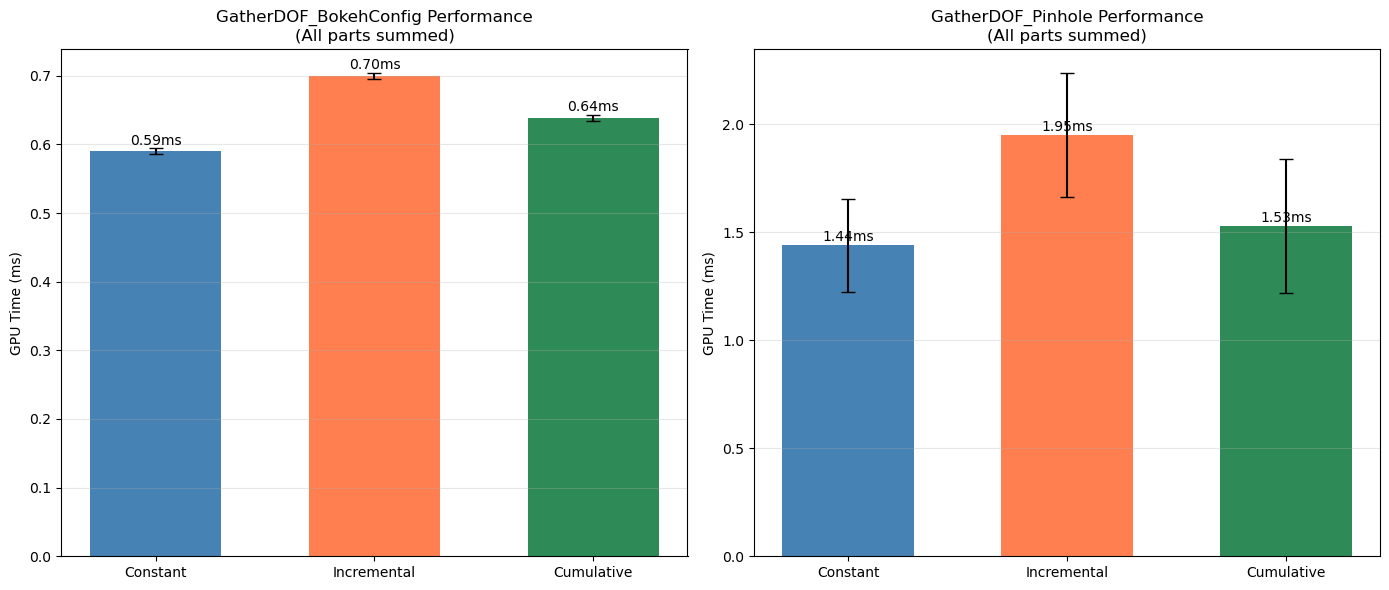


Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260317_153129\analysis_output\performance_comparison.svg

--- Bokeh Config Performance (GatherDOF_BokehConfig - All Parts) ---


,Method,Avg (ms),Std,Min (ms),Max (ms)
0,Constant,0.590428,0.004119,0.579584,0.600064
1,Incremental,0.699740,0.004068,0.690176,0.709632
2,Cumulative,0.638525,0.003808,0.628736,0.647168



Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260317_153129\analysis_output\performance_bokeh_config.csv

--- Scene Performance (GatherDOF_Pinhole - All Parts) ---


,Method,Avg (ms),Std,Min (ms),Max (ms)
0,Constant,1.439899,0.215215,0.707648,1.536480
1,Incremental,1.950785,0.286552,0.914176,2.080224
2,Cumulative,1.529190,0.310619,0.782656,1.698080



Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260317_153129\analysis_output\performance_scene.csv


In [7]:
# Performance Analysis Functions

def extract_timing_by_prefix(profiling_data, prefix):
    """
    Extract sum of GPU timings for all entries matching the prefix.
    profiling_data: dict with 'frames' key containing profiling data
    prefix: string to match at the start of timing keys (e.g., 'CS: GatherDOF_BokehConfig')
    Returns: list of summed GPU times per frame
    """
    frame_times = []
    for frame in profiling_data['frames']:
        total_gpu_time = 0.0
        for key, values in frame['timings'].items():
            if key.startswith(prefix):
                # values = [cpu_time, gpu_time]
                total_gpu_time += values[1]
        frame_times.append(total_gpu_time)
    return frame_times

def extract_timing_containing(profiling_data, pattern):
    """
    Extract sum of GPU timings for all entries containing the pattern.
    profiling_data: dict with 'frames' key containing profiling data
    pattern: string to search for in timing keys (e.g., 'GatherDOF_BokehConfig')
    Returns: list of summed GPU times per frame
    """
    frame_times = []
    for frame in profiling_data['frames']:
        total_gpu_time = 0.0
        for key, values in frame['timings'].items():
            if pattern in key:
                # values = [cpu_time, gpu_time]
                total_gpu_time += values[1]
        frame_times.append(total_gpu_time)
    return frame_times

def extract_timing_exact(profiling_data, timing_name):
    """
    Extract GPU timing for an exact timing key match.
    Returns: list of GPU times per frame
    """
    frame_times = []
    for frame in profiling_data['frames']:
        if timing_name in frame['timings']:
            frame_times.append(frame['timings'][timing_name][1])
        else:
            frame_times.append(0.0)
    return frame_times

def get_available_timing_keys(profiling_data, filter_pattern=None):
    """Get all unique timing keys from profiling data, optionally filtered."""
    keys = set()
    for frame in profiling_data['frames']:
        for key in frame['timings'].keys():
            if filter_pattern is None or filter_pattern.lower() in key.lower():
                keys.add(key)
    return sorted(keys)

def compute_timing_stats(frame_times):
    """Compute statistics for timing data"""
    return {
        'avg': np.mean(frame_times),
        'min': np.min(frame_times),
        'max': np.max(frame_times),
        'std': np.std(frame_times)
    }

# First, inspect what timing keys are available
print("=" * 60)
print("AVAILABLE TIMING KEYS (GatherDOF related)")
print("=" * 60)

print("\n--- Bokeh Config (constant) ---")
bokeh_keys = get_available_timing_keys(bokeh_profiling['constant'], 'GatherDOF')
for key in bokeh_keys:
    print(f"  {key}")

print("\n--- Scene (constant) ---")
scene_keys = get_available_timing_keys(scene_profiling['constant'], 'GatherDOF')
for key in scene_keys:
    print(f"  {key}")

# Define the pattern to match (all parts of the specific GatherDOF)
BOKEH_GATHER_PATTERN = 'GatherDOF_BokehConfig'
SCENE_GATHER_PATTERN = 'GatherDOF_Pinhole'

def extract_gatherdof_timing(profiling_data, pattern):
    """
    Extract timing for all GatherDOF operations matching the pattern.
    Sums ALL parts (CS:, Tex:, etc.) that contain the pattern.
    """
    # Get all available keys
    all_keys = get_available_timing_keys(profiling_data)
    
    # Find all keys containing the pattern
    matching_keys = [k for k in all_keys if pattern in k]
    
    if not matching_keys:
        print(f"  Warning: No keys found containing '{pattern}'")
        return [0.0] * len(profiling_data['frames']), []
    
    # Sum timings for all matching keys
    frame_times = []
    for frame in profiling_data['frames']:
        total_gpu_time = 0.0
        for key in matching_keys:
            if key in frame['timings']:
                total_gpu_time += frame['timings'][key][1]
        frame_times.append(total_gpu_time)
    
    return frame_times, matching_keys

# Extract GatherDOF_BokehConfig timings for bokeh_config (all parts)
print("\n" + "=" * 60)
print("BOKEH CONFIG - GatherDOF_BokehConfig Performance (All Parts)")
print("=" * 60)

bokeh_perf = {}
for method in ['constant', 'incremental', 'cumulative']:
    result = extract_gatherdof_timing(bokeh_profiling[method], BOKEH_GATHER_PATTERN)
    cs_times, matched_keys = result
    stats = compute_timing_stats(cs_times)
    bokeh_perf[method] = {'frame_times': cs_times, 'stats': stats, 'keys': matched_keys}
    print(f"{method.capitalize():15} - Avg: {stats['avg']:.3f}ms, Min: {stats['min']:.3f}ms, Max: {stats['max']:.3f}ms")
    print(f"  Measured keys ({len(matched_keys)}):")
    for key in matched_keys:
        print(f"    - {key}")

# Extract GatherDOF_Pinhole timings for scene (all parts)
print("\n" + "=" * 60)
print("SCENE - GatherDOF_Pinhole Performance (All Parts)")
print("=" * 60)

scene_perf = {}
for method in ['constant', 'incremental', 'cumulative']:
    result = extract_gatherdof_timing(scene_profiling[method], SCENE_GATHER_PATTERN)
    cs_times, matched_keys = result
    stats = compute_timing_stats(cs_times)
    scene_perf[method] = {'frame_times': cs_times, 'stats': stats, 'keys': matched_keys}
    print(f"{method.capitalize():15} - Avg: {stats['avg']:.3f}ms, Min: {stats['min']:.3f}ms, Max: {stats['max']:.3f}ms")
    print(f"  Measured keys ({len(matched_keys)}):")
    for key in matched_keys:
        print(f"    - {key}")

# Create comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

methods_labels = ['Constant', 'Incremental', 'Cumulative']
x = np.arange(len(methods_labels))
width = 0.6

# Bokeh Config performance
bokeh_avgs = [bokeh_perf[m]['stats']['avg'] for m in ['constant', 'incremental', 'cumulative']]
bokeh_errs = [bokeh_perf[m]['stats']['std'] for m in ['constant', 'incremental', 'cumulative']]
bars1 = axes[0].bar(x, bokeh_avgs, width, yerr=bokeh_errs, capsize=5, color=['steelblue', 'coral', 'seagreen'])
axes[0].set_ylabel('GPU Time (ms)')
axes[0].set_title('GatherDOF_BokehConfig Performance\n(All parts summed)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods_labels)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, bokeh_avgs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.2f}ms', 
                 ha='center', va='bottom', fontsize=10)

# Scene performance
scene_avgs = [scene_perf[m]['stats']['avg'] for m in ['constant', 'incremental', 'cumulative']]
scene_errs = [scene_perf[m]['stats']['std'] for m in ['constant', 'incremental', 'cumulative']]
bars2 = axes[1].bar(x, scene_avgs, width, yerr=scene_errs, capsize=5, color=['steelblue', 'coral', 'seagreen'])
axes[1].set_ylabel('GPU Time (ms)')
axes[1].set_title('GatherDOF_Pinhole Performance\n(All parts summed)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(methods_labels)
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, scene_avgs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.2f}ms', 
                 ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "performance_comparison.svg", format='svg', bbox_inches='tight')
plt.show()
print(f"\nSaved: {OUTPUT_DIR / 'performance_comparison.svg'}")

# Create CSV tables
bokeh_perf_df = pd.DataFrame({
    'Method': methods_labels,
    'Avg (ms)': bokeh_avgs,
    'Std': [bokeh_perf[m]['stats']['std'] for m in ['constant', 'incremental', 'cumulative']],
    'Min (ms)': [bokeh_perf[m]['stats']['min'] for m in ['constant', 'incremental', 'cumulative']],
    'Max (ms)': [bokeh_perf[m]['stats']['max'] for m in ['constant', 'incremental', 'cumulative']]
})

scene_perf_df = pd.DataFrame({
    'Method': methods_labels,
    'Avg (ms)': scene_avgs,
    'Std': [scene_perf[m]['stats']['std'] for m in ['constant', 'incremental', 'cumulative']],
    'Min (ms)': [scene_perf[m]['stats']['min'] for m in ['constant', 'incremental', 'cumulative']],
    'Max (ms)': [scene_perf[m]['stats']['max'] for m in ['constant', 'incremental', 'cumulative']]
})

# Save CSV files
bokeh_perf_df.to_csv(OUTPUT_DIR / "performance_bokeh_config.csv", index=False)
scene_perf_df.to_csv(OUTPUT_DIR / "performance_scene.csv", index=False)

print(f"\n--- Bokeh Config Performance (GatherDOF_BokehConfig - All Parts) ---")
display(bokeh_perf_df)
print(f"\nSaved: {OUTPUT_DIR / 'performance_bokeh_config.csv'}")

print(f"\n--- Scene Performance (GatherDOF_Pinhole - All Parts) ---")
display(scene_perf_df)
print(f"\nSaved: {OUTPUT_DIR / 'performance_scene.csv'}")

## Compare Quality & Performance

TAP COUNT (converted to SPP) COMPARISON - CONSTANT
Quality & Performance:


,SPP,PSNR,SSIM,L1,avg_ms,min_ms,max_ms,std_ms
0,1,9.156696,0.598552,0.193251,0.194888,0.191488,0.199680,0.001964
1,25,9.145664,0.436130,0.200640,0.433203,0.424960,0.439296,0.003440
2,100,9.841996,0.405516,0.189313,1.181194,1.162240,1.202176,0.007217
3,400,10.320724,0.403942,0.176201,4.266578,4.145152,4.342784,0.039749
4,1600,10.353971,0.432612,0.170365,16.895498,16.336894,17.245184,0.145557
5,3600,10.356959,0.462696,0.169165,39.511020,38.847488,40.381442,0.297874
6,6400,10.354591,0.488170,0.169005,70.155847,69.328901,72.093693,0.390458



TAP COUNT (converted to SPP) COMPARISON - INCREMENTAL
Quality & Performance:


,SPP,PSNR,SSIM,L1,avg_ms,min_ms,max_ms,std_ms
0,1,9.412442,0.630236,0.185754,0.199997,0.195584,0.203776,0.001760
1,25,12.195538,0.655537,0.120793,0.545044,0.538624,0.551936,0.002739
2,100,15.992088,0.685696,0.072700,1.649715,1.626112,1.676288,0.010208
3,400,19.243965,0.724232,0.049876,6.173174,5.989376,6.396928,0.059899
4,1600,20.222891,0.772984,0.045302,25.667584,24.796161,26.773504,0.426210
5,3600,20.409315,0.806133,0.045085,59.424144,57.981951,62.575617,0.766379
6,6400,20.470409,0.828989,0.045107,105.704049,104.158203,107.105286,0.668017



TAP COUNT (converted to SPP) COMPARISON - CUMULATIVE
Quality & Performance:


,SPP,PSNR,SSIM,L1,avg_ms,min_ms,max_ms,std_ms
0,1,9.399847,0.629976,0.186092,0.196833,0.193536,0.200704,0.001530
1,25,12.165917,0.655349,0.121289,0.481413,0.474112,0.489472,0.003352
2,100,16.023615,0.686196,0.072405,1.381100,1.359872,1.397760,0.008669
3,400,19.239841,0.723822,0.049858,5.100882,5.011456,5.212160,0.037725
4,1600,20.243576,0.772224,0.045190,20.694937,20.286465,21.354495,0.214085
5,3600,20.389881,0.805787,0.045225,48.329994,47.430653,50.051071,0.470730
6,6400,20.446434,0.828916,0.045262,85.589504,84.603903,86.642686,0.389308



Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260317_153129\analysis_output\tap_count_constant.csv
Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260317_153129\analysis_output\tap_count_incremental.csv
Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260317_153129\analysis_output\tap_count_cumulative.csv


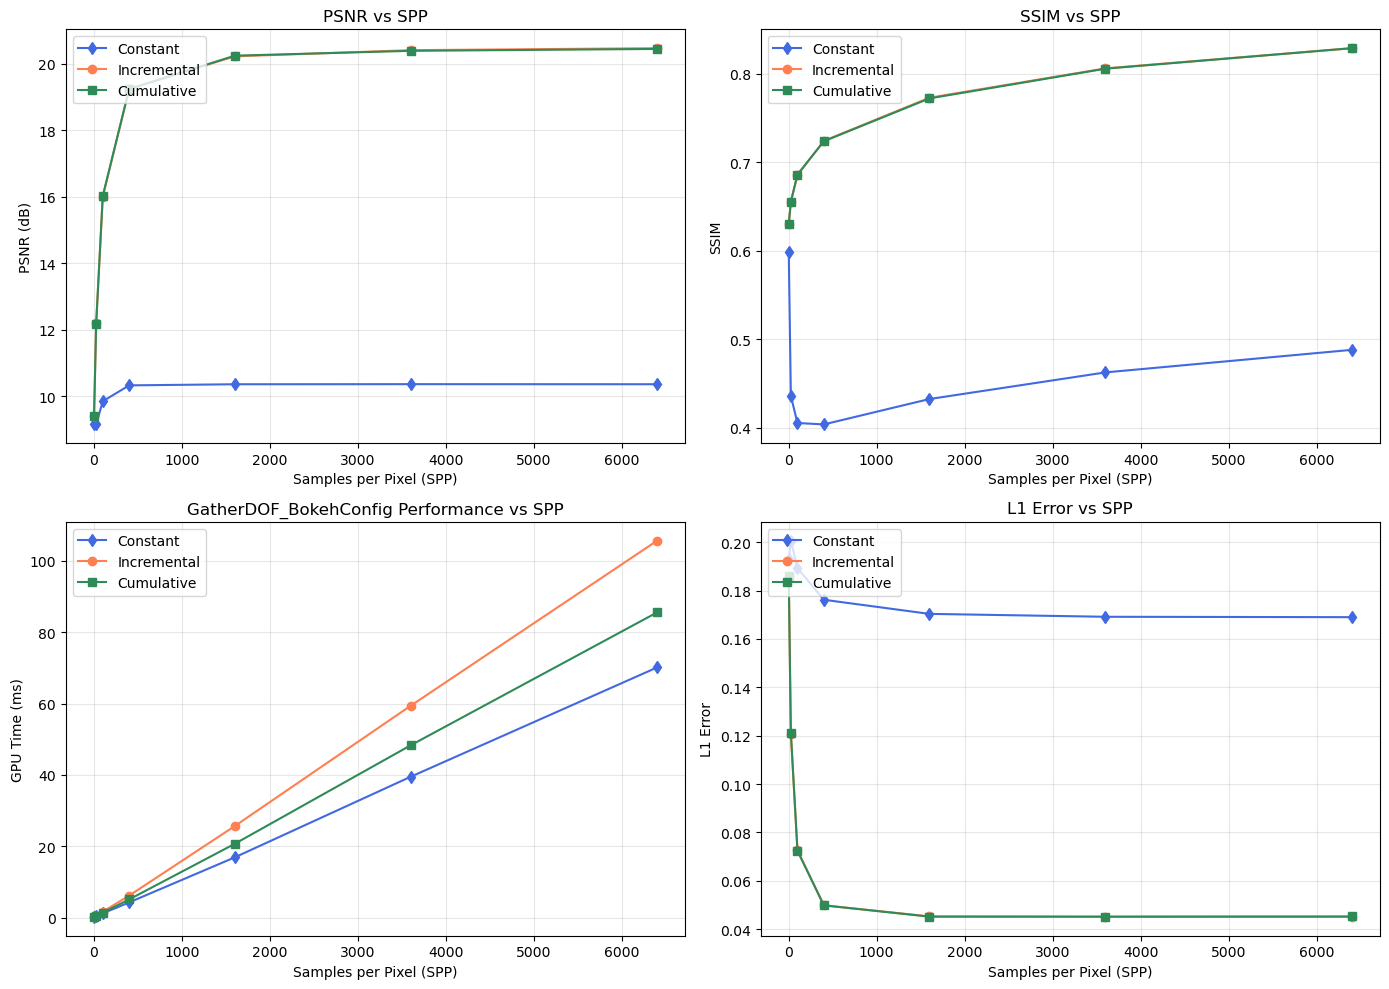


Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260317_153129\analysis_output\tap_count_quality_performance.svg


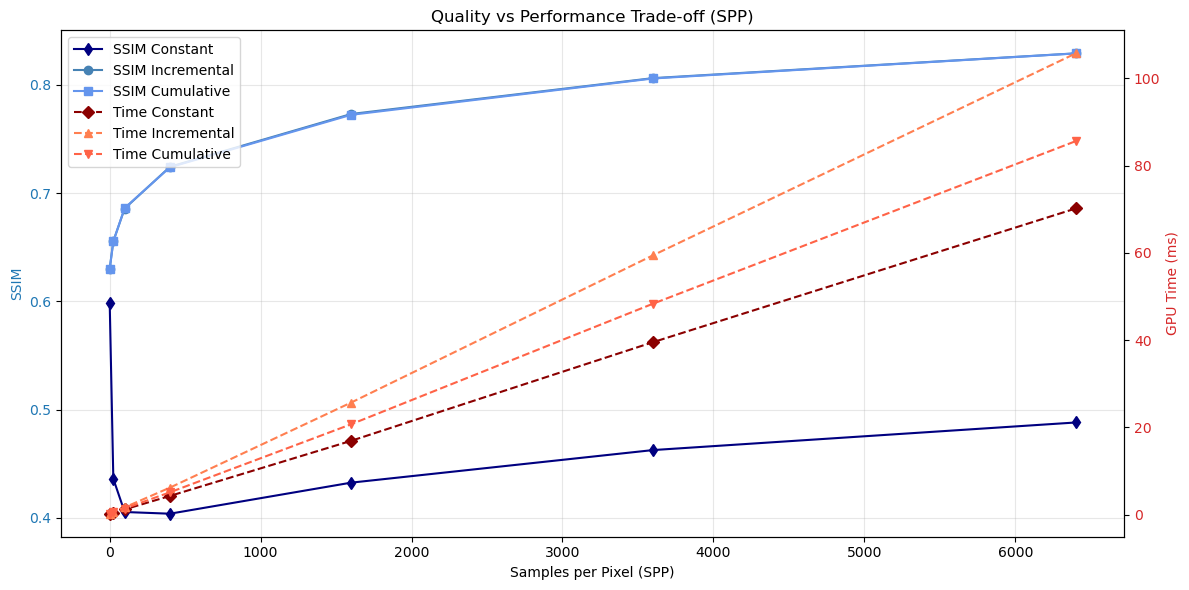

Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260317_153129\analysis_output\tap_count_quality_vs_performance.svg

SPP IMAGE GALLERY - CONSTANT


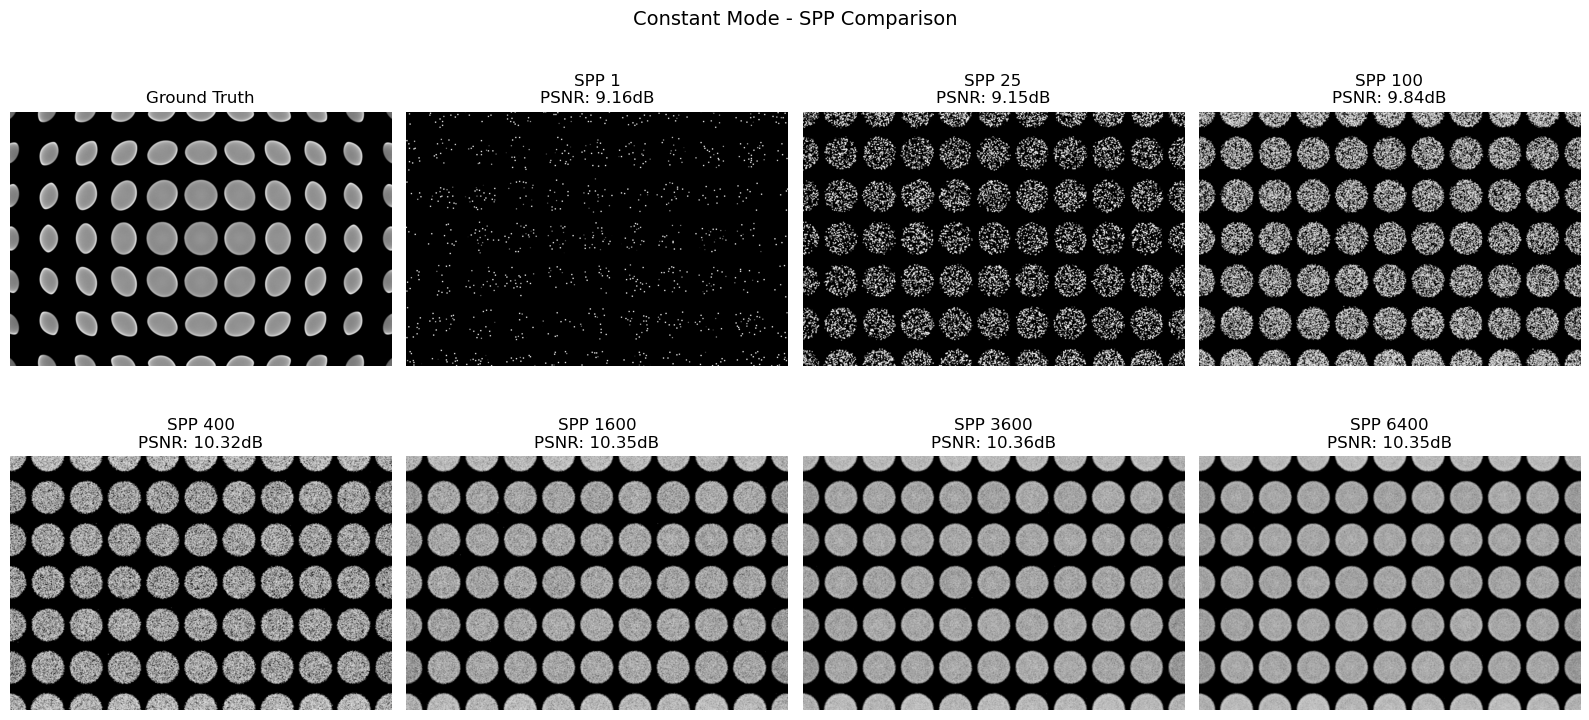


SPP IMAGE GALLERY - INCREMENTAL


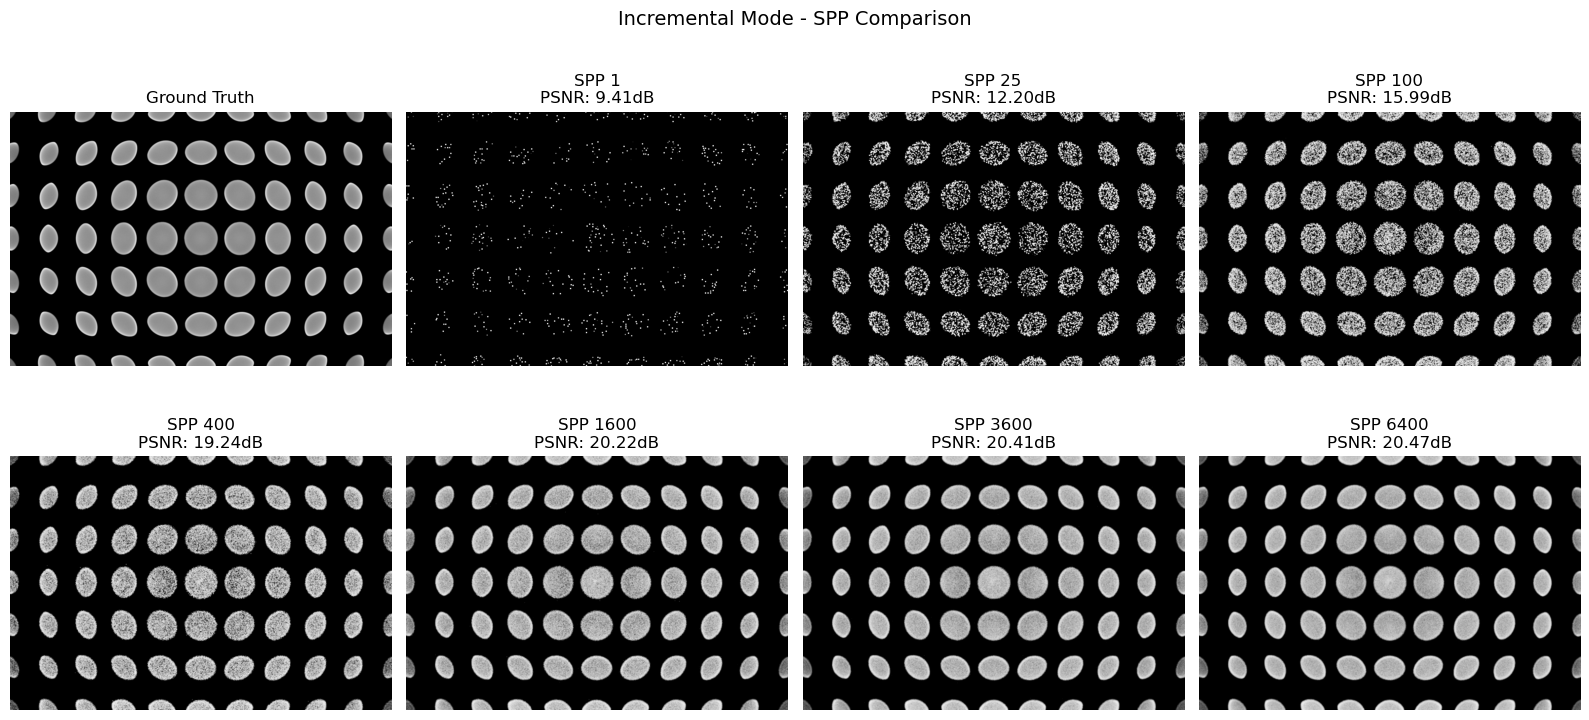


SPP IMAGE GALLERY - CUMULATIVE


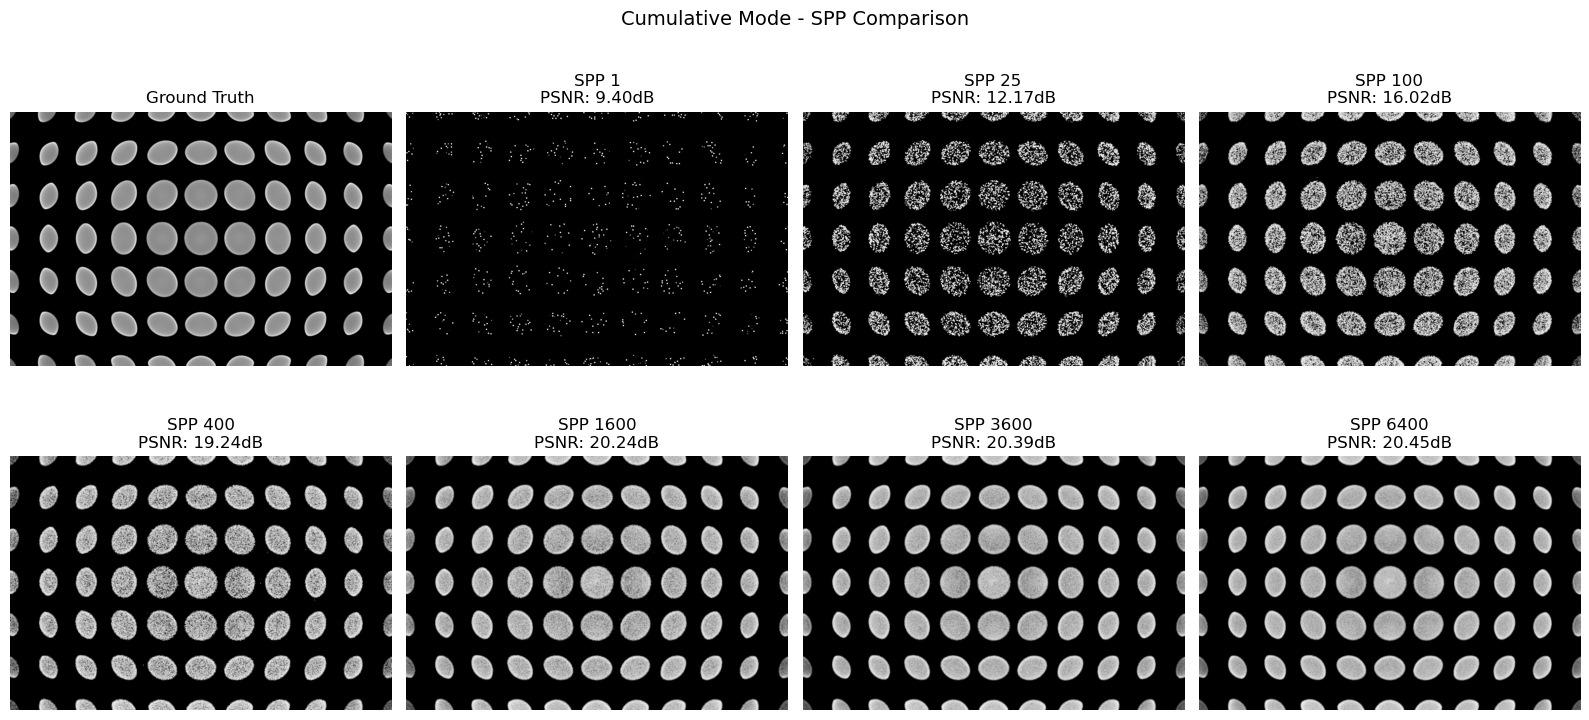


Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260317_153129\analysis_output\tap_count_gallery_constant.svg
Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260317_153129\analysis_output\tap_count_gallery_incremental.svg
Saved: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260317_153129\analysis_output\tap_count_gallery_cumulative.svg

ALL ANALYSIS COMPLETE
All outputs saved to: C:\Users\Chris\Documents\University\MasterThesis\Spatially-Varying-Bokeh\Demo\Gigi\profiling_results\20260317_153129\analysis_output


In [8]:
# Tap Count Comparison - Quality & Performance
# Compute PSNR and SSIM for each tap count compared to bokeh_config ground truth

gt_bokeh = bokeh_images['ground_truth']

# Collect metrics for all three modes
tap_metrics = {'constant': [], 'incremental': [], 'cumulative': []}
tap_performance = {'constant': [], 'incremental': [], 'cumulative': []}

# Compute SPP values (samples per pixel = tap_count squared)
spp_counts = [tc**2 for tc in tap_counts]

for mode in ['constant', 'incremental', 'cumulative']:
    for tc in tap_counts:
        spp = tc ** 2
        # Quality metrics
        img = tap_count_data[mode][tc]['image']
        psnr = compute_psnr(gt_bokeh, img)
        ssim_val = compute_ssim(gt_bokeh, img)
        l1 = compute_l1_error(gt_bokeh, img)
        tap_metrics[mode].append({
            'SPP': spp,
            'PSNR': psnr,
            'SSIM': ssim_val,
            'L1': l1
        })
        
        # Performance metrics - extract GatherDOF_BokehConfig timing
        profiling = tap_count_data[mode][tc]['profiling']
        cs_times = extract_timing_by_prefix(profiling, 'CS: GatherDOF_BokehConfig')
        stats = compute_timing_stats(cs_times)
        tap_performance[mode].append({
            'SPP': spp,
            'avg_ms': stats['avg'],
            'min_ms': stats['min'],
            'max_ms': stats['max'],
            'std_ms': stats['std']
        })

# Display metrics tables
print("=" * 60)
print("TAP COUNT (converted to SPP) COMPARISON - CONSTANT")
print("=" * 60)

const_quality_df = pd.DataFrame(tap_metrics['constant'])
const_perf_df = pd.DataFrame(tap_performance['constant'])
const_combined_df = pd.merge(const_quality_df, const_perf_df, on='SPP')
print("Quality & Performance:")
display(const_combined_df)

print("\n" + "=" * 60)
print("TAP COUNT (converted to SPP) COMPARISON - INCREMENTAL")
print("=" * 60)

inc_quality_df = pd.DataFrame(tap_metrics['incremental'])
inc_perf_df = pd.DataFrame(tap_performance['incremental'])
inc_combined_df = pd.merge(inc_quality_df, inc_perf_df, on='SPP')
print("Quality & Performance:")
display(inc_combined_df)

print("\n" + "=" * 60)
print("TAP COUNT (converted to SPP) COMPARISON - CUMULATIVE")
print("=" * 60)

cum_quality_df = pd.DataFrame(tap_metrics['cumulative'])
cum_perf_df = pd.DataFrame(tap_performance['cumulative'])
cum_combined_df = pd.merge(cum_quality_df, cum_perf_df, on='SPP')
print("Quality & Performance:")
display(cum_combined_df)

# Save CSV files (now containing SPP column)
const_combined_df.to_csv(OUTPUT_DIR / "tap_count_constant.csv", index=False)
inc_combined_df.to_csv(OUTPUT_DIR / "tap_count_incremental.csv", index=False)
cum_combined_df.to_csv(OUTPUT_DIR / "tap_count_cumulative.csv", index=False)
print(f"\nSaved: {OUTPUT_DIR / 'tap_count_constant.csv'}")
print(f"Saved: {OUTPUT_DIR / 'tap_count_incremental.csv'}")
print(f"Saved: {OUTPUT_DIR / 'tap_count_cumulative.csv'}")

# Plot Quality over SPP
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# PSNR over SPP
axes[0, 0].plot(spp_counts, [m['PSNR'] for m in tap_metrics['constant']], 'd-', label='Constant', color='royalblue')
axes[0, 0].plot(spp_counts, [m['PSNR'] for m in tap_metrics['incremental']], 'o-', label='Incremental', color='coral')
axes[0, 0].plot(spp_counts, [m['PSNR'] for m in tap_metrics['cumulative']], 's-', label='Cumulative', color='seagreen')
axes[0, 0].set_xlabel('Samples per Pixel (SPP)')
axes[0, 0].set_ylabel('PSNR (dB)')
axes[0, 0].set_title('PSNR vs SPP')
axes[0, 0].legend(loc='upper left')
axes[0, 0].grid(True, alpha=0.3)

# SSIM over SPP
axes[0, 1].plot(spp_counts, [m['SSIM'] for m in tap_metrics['constant']], 'd-', label='Constant', color='royalblue')
axes[0, 1].plot(spp_counts, [m['SSIM'] for m in tap_metrics['incremental']], 'o-', label='Incremental', color='coral')
axes[0, 1].plot(spp_counts, [m['SSIM'] for m in tap_metrics['cumulative']], 's-', label='Cumulative', color='seagreen')
axes[0, 1].set_xlabel('Samples per Pixel (SPP)')
axes[0, 1].set_ylabel('SSIM')
axes[0, 1].set_title('SSIM vs SPP')
axes[0, 1].legend(loc='upper left')
axes[0, 1].grid(True, alpha=0.3)

# Performance over SPP
axes[1, 0].plot(spp_counts, [p['avg_ms'] for p in tap_performance['constant']], 'd-', label='Constant', color='royalblue')
axes[1, 0].plot(spp_counts, [p['avg_ms'] for p in tap_performance['incremental']], 'o-', label='Incremental', color='coral')
axes[1, 0].plot(spp_counts, [p['avg_ms'] for p in tap_performance['cumulative']], 's-', label='Cumulative', color='seagreen')
axes[1, 0].set_xlabel('Samples per Pixel (SPP)')
axes[1, 0].set_ylabel('GPU Time (ms)')
axes[1, 0].set_title('GatherDOF_BokehConfig Performance vs SPP')
axes[1, 0].legend(loc='upper left')
axes[1, 0].grid(True, alpha=0.3)

# L1 Error over SPP
axes[1, 1].plot(spp_counts, [m['L1'] for m in tap_metrics['constant']], 'd-', label='Constant', color='royalblue')
axes[1, 1].plot(spp_counts, [m['L1'] for m in tap_metrics['incremental']], 'o-', label='Incremental', color='coral')
axes[1, 1].plot(spp_counts, [m['L1'] for m in tap_metrics['cumulative']], 's-', label='Cumulative', color='seagreen')
axes[1, 1].set_xlabel('Samples per Pixel (SPP)')
axes[1, 1].set_ylabel('L1 Error')
axes[1, 1].set_title('L1 Error vs SPP')
axes[1, 1].legend(loc='upper left')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "tap_count_quality_performance.svg", format='svg', bbox_inches='tight')
plt.show()
print(f"\nSaved: {OUTPUT_DIR / 'tap_count_quality_performance.svg'}")

# Combined Quality-Performance Trade-off Plot (SPP)
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary axis - SSIM
ax1.set_xlabel('Samples per Pixel (SPP)')
ax1.set_ylabel('SSIM', color='tab:blue')
p0 = ax1.plot(spp_counts, [m['SSIM'] for m in tap_metrics['constant']], 'd-', 
              label='SSIM Constant', color='navy')
p1 = ax1.plot(spp_counts, [m['SSIM'] for m in tap_metrics['incremental']], 'o-', 
              label='SSIM Incremental', color='steelblue')
p2 = ax1.plot(spp_counts, [m['SSIM'] for m in tap_metrics['cumulative']], 's-', 
              label='SSIM Cumulative', color='cornflowerblue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

# Secondary axis - Performance
ax2 = ax1.twinx()
ax2.set_ylabel('GPU Time (ms)', color='tab:red')
p3 = ax2.plot(spp_counts, [p['avg_ms'] for p in tap_performance['constant']], 'D--', 
              label='Time Constant', color='darkred')
p4 = ax2.plot(spp_counts, [p['avg_ms'] for p in tap_performance['incremental']], '^--', 
              label='Time Incremental', color='coral')
p5 = ax2.plot(spp_counts, [p['avg_ms'] for p in tap_performance['cumulative']], 'v--', 
              label='Time Cumulative', color='tomato')
ax2.tick_params(axis='y', labelcolor='tab:red')

# Combined legend
plots = p0 + p1 + p2 + p3 + p4 + p5
labels = [p.get_label() for p in plots]
ax1.legend(plots, labels, loc='upper left')

plt.title('Quality vs Performance Trade-off (SPP)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "tap_count_quality_vs_performance.svg", format='svg', bbox_inches='tight')
plt.show()
print(f"Saved: {OUTPUT_DIR / 'tap_count_quality_vs_performance.svg'}")

# Visualize SPP images for all modes
print("\n" + "=" * 60)
print("SPP IMAGE GALLERY - CONSTANT")
print("=" * 60)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Ground truth
axes[0].imshow(gt_bokeh)
axes[0].set_title('Ground Truth')
axes[0].axis('off')

# SPP images (constant)
for idx, tc in enumerate(tap_counts):
    if idx < 7:
        spp = tc ** 2
        axes[idx+1].imshow(tap_count_data['constant'][tc]['image'])
        psnr = tap_metrics['constant'][idx]['PSNR']
        axes[idx+1].set_title(f'SPP {spp}\nPSNR: {psnr:.2f}dB')
        axes[idx+1].axis('off')

plt.suptitle('Constant Mode - SPP Comparison', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "tap_count_gallery_constant.svg", format='svg', bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("SPP IMAGE GALLERY - INCREMENTAL")
print("=" * 60)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Ground truth
axes[0].imshow(gt_bokeh)
axes[0].set_title('Ground Truth')
axes[0].axis('off')

# SPP images (incremental)
for idx, tc in enumerate(tap_counts):
    if idx < 7:
        spp = tc ** 2
        axes[idx+1].imshow(tap_count_data['incremental'][tc]['image'])
        psnr = tap_metrics['incremental'][idx]['PSNR']
        axes[idx+1].set_title(f'SPP {spp}\nPSNR: {psnr:.2f}dB')
        axes[idx+1].axis('off')

plt.suptitle('Incremental Mode - SPP Comparison', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "tap_count_gallery_incremental.svg", format='svg', bbox_inches='tight')
plt.show()

print("\n" + "=" * 60)
print("SPP IMAGE GALLERY - CUMULATIVE")
print("=" * 60)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

# Ground truth
axes[0].imshow(gt_bokeh)
axes[0].set_title('Ground Truth')
axes[0].axis('off')

# SPP images (cumulative)
for idx, tc in enumerate(tap_counts):
    if idx < 7:
        spp = tc ** 2
        axes[idx+1].imshow(tap_count_data['cumulative'][tc]['image'])
        psnr = tap_metrics['cumulative'][idx]['PSNR']
        axes[idx+1].set_title(f'SPP {spp}\nPSNR: {psnr:.2f}dB')
        axes[idx+1].axis('off')

plt.suptitle('Cumulative Mode - SPP Comparison', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "tap_count_gallery_cumulative.svg", format='svg', bbox_inches='tight')
plt.show()

print(f"\nSaved: {OUTPUT_DIR / 'tap_count_gallery_constant.svg'}")
print(f"Saved: {OUTPUT_DIR / 'tap_count_gallery_incremental.svg'}")
print(f"Saved: {OUTPUT_DIR / 'tap_count_gallery_cumulative.svg'}")

print("\n" + "=" * 60)
print("ALL ANALYSIS COMPLETE")
print("=" * 60)
print(f"All outputs saved to: {OUTPUT_DIR}")